In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, rv_continuous, mannwhitneyu
import time

In [103]:
PDF_X = np.linspace(-100, 100, 1000)
trapezoid = np.trapz

In [ ]:
from scipy.optimize import minimize_scalar

class AsymmetricGaussian(rv_continuous):
    """
    Custom Asymmetric Gaussian distribution.
    Use loc for the mean, and unc_minus/unc_plus as shape parameters.
    """
    def _pdf(self, x, unc_minus, unc_plus):
        """x is already shifted by loc internally by scipy"""
        pdf = np.where(
            x < 0,
            np.exp(-0.5 * (x / unc_minus)**2),
            np.exp(-0.5 * (x / unc_plus)**2)
        )
        
        norm = np.sqrt(2 / (np.pi * (unc_plus + unc_minus)**2))
        return norm * pdf

    def _rvs(self, unc_minus, unc_plus, size=None, random_state=None):
        """Generate random samples from the asymmetric Gaussian"""
        rng = np.random.default_rng()
        # To match _pdf, each side must carry mass unc/(unc_minus + unc_plus),
        # not 50/50: pick the side first, then draw a half-normal on that side
        left = rng.random(size) < unc_minus / (unc_minus + unc_plus)
        half = np.abs(rng.standard_normal(size))
        samples = np.where(left, -half * unc_minus, half * unc_plus)
        return samples

def bc(pdf1, pdf2, x=PDF_X):
    """The bhattacharyya coefficient of PDF1 and PDF2, defined over x"""
    return trapezoid(np.sqrt(pdf1*pdf2), x=x)

# Not very useful
# Potentially consider renormalization of the hellinger_dist
def hellinger_dist(pdf1, pdf2, x=PDF_X):
    return np.sqrt((1-bc(pdf1, pdf2, x)))

def bc_norm_median(mean1, mean2, std1, std2, x=PDF_X):

    reference_pdf = norm.pdf(x, loc=mean1, scale=std1)
    test_pdf = norm.pdf(x, loc=mean2, scale=std2)
    maxtest_pdf = norm.pdf(x, loc=mean1, scale=std2)  

    bc_true = bc(reference_pdf, test_pdf)
    bc_max = bc(reference_pdf, maxtest_pdf)
        
    return bc_true/bc_max

def bc_norm_median_asymmetric(mean1, mean2, std1, unc_minus, unc_plus, x=PDF_X):

    reference_pdf = norm.pdf(x, loc=mean1, scale=std1)
    test_pdf = AsymmetricGaussian().pdf(x, loc=mean2, unc_minus=unc_minus, unc_plus=unc_plus)

    def neg_bc_at(loc):
        shifted_pdf = AsymmetricGaussian().pdf(x, loc=loc, unc_minus=unc_minus, unc_plus=unc_plus)
        return -bc(reference_pdf, shifted_pdf)

    opt = minimize_scalar(neg_bc_at, bounds=(x[0], x[-1]), method="bounded")
    bc_max = -opt.fun

    bc_true = bc(reference_pdf, test_pdf)

    return bc_true/bc_max

def bc_norm_median_asymmetric_unnorm(mean1, mean2, std1, unc_minus, unc_plus, x=PDF_X):

    reference_pdf = norm.pdf(x, loc=mean1, scale=std1)
    test_pdf = AsymmetricGaussian().pdf(x, loc=mean2, unc_minus=unc_minus, unc_plus=unc_plus)

    shift_from_mean = (unc_plus-unc_minus)/2
    
    maxtest_pdf = AsymmetricGaussian().pdf(x, loc=mean1-shift_from_mean, unc_minus=unc_minus, unc_plus=unc_plus)  

    bc_true = bc(reference_pdf, test_pdf)
    bc_max = bc(reference_pdf, maxtest_pdf)

    return bc_true/bc_max

def mwu(mean1, mean2, std1, unc_minus, unc_plus, x=PDF_X):

    reference_pdf = norm.pdf(x, loc=mean1, scale=std1)
    test_pdf = AsymmetricGaussian().pdf(x, loc=mean2, unc_minus=unc_minus, unc_plus=unc_plus)

    res = mannwhitneyu(reference_pdf, test_pdf, alternative="two-sided")
    return res.pvalue

def zscore(mean1, mean2, std1, pdf=norm.pdf, *args, **kwargs):
    zscore = (mean2 - mean1) / std1
    return pdf(zscore) / pdf(0)

def resampled_zscore(mean1, mean2, std1, unc_minus, unc_plus, x=PDF_X):
    # Samples 1M values from an asymmetric guassian with the same mean and uncertainty values
    test_rand_values = AsymmetricGaussian().rvs(size=1_000_000, loc=mean2, unc_minus=unc_minus, unc_plus=unc_plus)    
    # Measures the z-scores of all of these values with respect to the provided mean
    resampled_zscores = zscore(mean1, test_rand_values, std1)
    # Returns the median of all of the z-scores
    return np.quantile(resampled_zscores, 0.5)

ag = AsymmetricGaussian()

In [ ]:
base_std = 5
base_pdf = ag.pdf(PDF_X, loc=0, unc_minus=base_std, unc_plus=base_std)

test_pdfs = dict(
    base_pdf = dict(loc=0,unc_minus=5, unc_plus=5),
    deltafunc_pdf = dict(loc=0, unc_minus=1, unc_plus=1),
    deltafunc_slightly_offset_pdf = dict(loc=5, unc_minus=1, unc_plus=1),
    deltafunc_offset_pdf = dict(loc=50, unc_minus=1, unc_plus=1),
    wide_pdf = dict(loc=0,unc_minus=10, unc_plus=10),
    # same slight offset as deltafunc_slightly_offset_pdf, but wide: a good
    # metric should score this at least as high as the narrow version
    wide_slightly_offset_pdf = dict(loc=5, unc_minus=10, unc_plus=10),
    wide_pdf_offset = dict(loc=15, unc_minus=10, unc_plus=10),
    wide_pdf_veryoffset = dict(loc=50,unc_minus=10, unc_plus=10),
    verywide_pdf = dict(loc=0,unc_minus=50, unc_plus=50),
    verywide_slightly_offset_pdf = dict(loc=5,unc_minus=50, unc_plus=50),
    verywide_pdf_offset = dict(loc=50,unc_minus=50, unc_plus=50),
    asymmetric_pdf_deltafunc = dict(loc=0, unc_minus=0.5, unc_plus=1),
    asymmetric_pdf_deltafunc_offset = dict(loc=50, unc_minus=0.5, unc_plus=1),
    asymmetric_pdf_wide = dict(loc=0, unc_minus=7.5, unc_plus=12.5),
    asymmetric_pdf_wide_offset = dict(loc=50, unc_minus=7.5, unc_plus=12.5),
    asymmetric_pdf_wide_offset_neg = dict(loc=-50, unc_minus=7.5, unc_plus=12.5),
    asymmetric_pdf_very_skewed = dict(loc=0, unc_minus=50, unc_plus=1),
    asymmetric_pdf_very_skewed_offset = dict(loc=20, unc_minus=50, unc_plus=1),
    asymmetric_pdf_very_skewed_very_offset_pos = dict(loc=80, unc_minus=50, unc_plus=1),
    asymmetric_pdf_very_skewed_very_offset_neg = dict(loc=-80, unc_minus=50, unc_plus=1),
    # Transition-zone edge cases: host slightly BELOW the GW mean with a tiny
    # facing (upper) tail but a huge far (lower) tail. The discrete tail pick
    # only sees unc_plus=1 and punishes these hosts even though their total
    # uncertainty is enormous; a smooth tail mixture keeps them high,
    # consistent with "close + very uncertain => worth more telescope time".
    asymmetric_pdf_very_skewed_slightly_offset_neg = dict(loc=-5, unc_minus=50, unc_plus=1),
    asymmetric_pdf_very_skewed_moderately_offset_neg = dict(loc=-8, unc_minus=50, unc_plus=1),
)

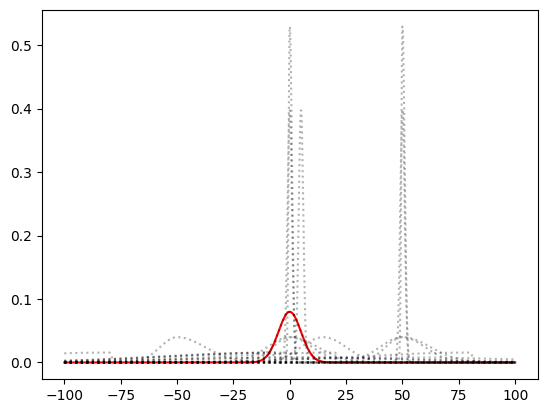

In [106]:
fig, ax = plt.subplots()

ax.plot(PDF_X, base_pdf, color="r")

for label, test_params in test_pdfs.items():
    test = ag.pdf(PDF_X, **test_params)
    ax.plot(PDF_X, test, color="k", alpha=0.3, linestyle=":")

In [107]:
# table = "name,bhattacharyya_coefficient,normalized_bhattacharyya_coefficient,simple_zscore,resampled_zscore\n"

# start = time.perf_counter()

for label, test in test_pdfs.items():
    test_pdf = ag.pdf(PDF_X, **test)
    norm_bc = bc_norm_median_asymmetric(0, test["loc"], 5, test["unc_minus"], test["unc_plus"])
    mwu_res = mwu(0, test["loc"], 5, test["unc_minus"], test["unc_plus"])
    z = zscore(0, test["loc"], base_std)
    z_resampled = resampled_zscore(0, test["loc"], base_std, test["unc_minus"], test["unc_plus"])
    
    old_bc = bc(base_pdf, test_pdf)
    
    print(label, z, z_resampled)

    # fig, ax = plt.subplots()
    # ax.plot(PDF_X, base_pdf, color="r", label="Sample GW PDF", alpha=0.5)
    # ax.plot(PDF_X, test_pdf, color="k", label="Sample Host PDF", alpha=0.5)
    # ax.legend()
    # ax.set_title(f"{label}:\nnorm_score={norm_bc:.3f}\nold_score={old_bc:.3f}\nzscore={z:.3f}\nresampled_zscore={z_resampled:.3f}")
    # # fig.savefig(label+".png")

# end = time.perf_counter()
# print(f'Time Elapsed: {end - start}')

base_pdf 1.0 0.7969751636275801
deltafunc_pdf 1.0 0.9909571888181323
deltafunc_slightly_offset_pdf 0.6065306597126334 0.6064468336045346
deltafunc_offset_pdf 1.9287498479639178e-22 1.9184643839004647e-22
wide_pdf 1.0 0.4014275186665498
wide_pdf_offset 0.011108996538242306 0.010798173101179816
wide_pdf_veryoffset 1.9287498479639178e-22 2.0090556020716392e-22
verywide_pdf 1.0 1.240599333742691e-10
verywide_slightly_offset_pdf 0.6065306597126334 1.0539304131799298e-10
verywide_pdf_offset 1.9287498479639178e-22 1.1468256872905096e-24
asymmetric_pdf_deltafunc 1.0 0.9945828874886371
asymmetric_pdf_deltafunc_offset 1.9287498479639178e-22 1.0156780990653487e-22
asymmetric_pdf_wide 1.0 0.3913015746858224
asymmetric_pdf_wide_offset 1.9287498479639178e-22 2.7582448082451537e-25
asymmetric_pdf_wide_offset_neg 1.9287498479639178e-22 9.120026908454951e-20
asymmetric_pdf_very_skewed 1.0 3.944759409550534e-10
asymmetric_pdf_very_skewed_offset 0.00033546262790251185 0.002034613637550616
asymmetric_pdf_

In [108]:
# Self-Entropy
# Sum of -p_i*log(p_i)
# Add a minimum bound to prevent log(0) errors

def shannon_entropy(pdf, eps=1e-85):
    pdf = np.asarray(pdf, dtype=float)
    # Normalization
    pdf = pdf / np.sum(pdf)
    pdf = np.clip(pdf, eps, None)
    return float(np.sum(-pdf * np.log2(pdf)))

# Relative Entropy Calculations
# D(P || Q) = sum_i p_i * log2(p_i / q_i)
# This is non-negative when both inputs are valid probability distributions.
def relative_entropy(p, q, eps=1e-85):
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)

    if p.shape != q.shape:
        raise ValueError("p and q must have the same shape")

    p = p / np.sum(p)
    q = q / np.sum(q)

    p = np.clip(p, eps, None)
    q = np.clip(q, eps, None)

    return float(np.sum(p * np.log2(p / q)))

# JSD (Jensen-Shannon Divergence)
# JSD(P || Q) = 0.5 * D(P || M) + 0.5 * D(Q || M)
# where M = 0.5 * (P + Q). With base-2 logs, JSD is bounded between 0 and 1.
# 0 means that the distributions are very similar, and 1 means that they are completely different
def jsd(p, q, eps=1e-85):
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)

    # Normalization of PDFs
    p = p / np.sum(p)
    q = q / np.sum(q)

    m = 0.5 * (p + q)
    jsd_value = 0.5 * relative_entropy(p, m, eps=eps) + 0.5 * relative_entropy(q, m, eps=eps)
    return float(jsd_value)

# Consider a better way to measure how uniform the function is
# Current problem is that heavily skewed PDFs are getting a very low score in compare uniform
# even though they are fairly well-known, and this is inflating the asymmetric_pdf_skewed scores
def compare_uniform(p, eps=1e-15):
    # Instead of naively generating the uniform distribution across p's entire domain
    # only generate uniform_dist across the region where p > eps
    uniform_dist = np.full_like(p, 1.0 / len(p))
    return jsd(uniform_dist, p)

# This is not really giving very good results
# Entropy comparison to uniform distribution
def entropy_comp_uniform(p):
    # np.log2(len(p)) is the entropy of a completely uniform distribution
    return 1 - (shannon_entropy(p) / np.log2(len(p)))

def raw_zscore(mean1, mean2, std):
    return (mean2 - mean1) / std

In [109]:
# Not sure if this is a meaningful metric because of arbitrary normalization
import numpy as np
from scipy.stats import wasserstein_distance

def get_alignment_score(x_grid, p, q):
    # Measures how much "work" is required to transform q --> p
    # by measuring the probability mass and the distance it must travel
    # Learn some more detail about exactly how this works mathematically
    emd = wasserstein_distance(x_grid, x_grid, u_weights=p, v_weights=q)
    
    max_dist = x_grid[-1] - x_grid[0] 
    
    raw_score = 1.0 - (emd / max_dist)
    
    # Optional: Apply a non-linear power curve to penalize offsets aggressively
    return raw_score ** 2

In [110]:
# start = time.perf_counter()
for label, test in test_pdfs.items():
    test_pdf = ag.pdf(PDF_X, **test)

    # Normalization
    test_pdf = test_pdf / np.sum(test_pdf)
    base_pdf = base_pdf / np.sum(base_pdf)
    
    z_score = raw_zscore(0, test['loc'], base_std)

    # 0 --> Close to each other
    # 1 --> Far from each other
    jsd_val = jsd(test_pdf, base_pdf)
    # 0 --> Close to uniform 
    # 1 --> Far from uniform
    uni_comp = compare_uniform(test_pdf)

    # With this product, if test_pdf is very close to uniform distribution
    # then its final_score will be near 1, so the jsd_val does not impact this significantly
    # However, if the distribution is far from uniform, then uni_comp is near 1, so the final
    # score is completely dependent on the JSD val
    # Consider non-linear final score calculations as well

    # Currently, information theory metrics alone does not give any information
    # about alignment or spatial relations, so we need to combine these
    # The main problem is coming from delta functions, which are localized at the mean of the 
    # target distribution, but because they don't have the target distribution shape, they are 
    # getting penalized for it
    # Prioritize alignment score, fine_tune these weights
    inform_score = 1 - (jsd_val)
    zscored = zscore(0, test['loc'], base_std)

    # Conditional Scoring
    if uni_comp < 0.2:
        # Should this just be 1 or some small deviation?
        # No small deviation because if uni_comp is that low, then we don't know anything about
        # the function
        # final_score = 1 - uni_comp
        final_score = 1 - 0.05*(1-zscored)
    elif abs(z_score) < 0.3:
        # Consider introducing a little bit more information about how the distribution matches the target
        # Currently losing a bit too much
        final_score = 0.95*(zscored) + 0.05*(inform_score)
    else:
        final_score = 0.9*inform_score + 0.1*zscored

    fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)
    ax.plot(PDF_X, base_pdf, color="r", label="Sample GW PDF", alpha=0.5)
    ax.plot(PDF_X, test_pdf, color="k", label="Sample Host PDF", alpha=0.5)
    ax.legend()
    ax.set_title(f"{label}\nFinal Score: {final_score}", pad=12)
    fig.savefig(f"out/jsd_uniform/{label}.png", dpi=300, bbox_inches="tight")
    plt.close(fig)

# end = time.perf_counter()
# print(f'Time Elapsed: {end - start}')

# Think about how to improve these metrics such that plots like asymmetric delta_func and asymmetric very skewed still have very high scores
# Essentially, we don't necessarily want to measure the overlap of the PDFs, what we want to actually measure is whether the 2 PDFs peak 
# at the same place? 

# We could also consider a discrete type of scoring method with conditionals
# For example, if the JSD_Uniform is below a certain threshold, than the score is automatically one
# If the Z-Score is within a certain range, then the z-score should be the only thing determining the score
# If these 2 criteria are not satisfied, then use a naive implementation of 1 - (uni_comp * jsd_val)

# This method relies on tunable parameters like the thresholds

In [111]:
# Not good results
# Delta function getting uniform score of 0.6, should be much closer to 1
# for label, test in test_pdfs.items():
#     test_pdf = ag.pdf(PDF_X, **test)

#     # Normalization
#     test_pdf = test_pdf / np.sum(test_pdf)
#     base_pdf = base_pdf / np.sum(base_pdf)

#     # 0 --> Close to each other
#     # 1 --> Far from each other
#     jsd_val = jsd(test_pdf, base_pdf)
#     # 0 --> Close to uniform
#     # 1 --> Far from uniform
#     uni_comp = entropy_comp_uniform(test_pdf)

#     # With this product, if test_pdf is very close to uniform distribution
#     # then its final_score will be near 1, so the jsd_val does not impact this significantly
#     # However, if the distribution is far from uniform, then uni_comp is near 1, so the final
#     # score is completely dependent on the JSD val
#     final_score = 1 - (uni_comp * jsd_val)

#     fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)
#     ax.plot(PDF_X, base_pdf, color="r", label="Sample GW PDF", alpha=0.5)
#     ax.plot(PDF_X, test_pdf, color="k", label="Sample Host PDF", alpha=0.5)
#     ax.legend()
#     ax.set_title(f"{label}\nJSD Val: {jsd_val}\nUniform Comparison: {uni_comp}\n Final Score: {final_score}", pad=12)
#     fig.savefig(f"out/entropy_uniform/{label}.png", dpi=300, bbox_inches="tight")
#     plt.close(fig)

In [ ]:
from scipy.special import erfc
import numpy as np

def consistency_probability(mean1, mean2, std1, unc_minus, unc_plus, wt=3):

    if mean2 < mean1:
        # then the relevant tail is the upper side of the asymmetric distribution
        std2 = unc_plus
    else:
        std2 = unc_minus

    sigma_diff = wt*np.sqrt(2*(std1**2 + std2**2))
    mean_diff = np.abs(mean1 - mean2)

    # Reconsider the scaling for this to be a statistically meaningful result (like the p-value)
    score = erfc((mean_diff/sigma_diff))
    return score

def improved_cons_prob(mean1, mean2, std1, unc_minus, unc_plus, wt=3):
    # Use the z-score sign to decide which tail is more relevant, while letting
    # the uncertainty imbalance modulate that preference.

    mean_diff = np.abs(mean1 - mean2)

    naive_zscore = (mean2 - mean1) / std1

    # This scaling of 2 for the unc_plus/unc_minus is causing differences, but there isn't really any reason why this should be here
    sigma_diff_right = wt*np.sqrt(2*(std1**2 + (unc_plus)**2))
    sigma_diff_left = wt*np.sqrt(2*(std1**2 + (unc_minus)**2))

    right_score = erfc((mean_diff/sigma_diff_right)/(np.sqrt(2)))
    left_score = erfc((mean_diff/sigma_diff_left)/(np.sqrt(2)))

    # Positive when the left tail is wider than the right tail.
    # Is this the right measure of imbalance?
    imbalance = (unc_minus - unc_plus) / (unc_plus + unc_minus)

    # When the z-score is large, its sign dominates the preference.
    # When the z-score is near zero, the uncertainty imbalance takes over.
    z_strength = np.tanh(np.abs(naive_zscore))

    # Reconsider this process
    preference = z_strength + (1 - z_strength) * imbalance
    # This clipping may not be the best way, consider a non-linear mapping to [-1, 1] like tanh
    # preference = np.clip(preference, -1.0, 1.0)
    preference = np.tanh(preference)

    left_weight = 0.5 * (1 + preference)
    right_weight = 0.5 * (1 - preference)
    # The weights are actually reasonably different
    print(f'Left Weight: {left_weight} and Right Weight: {right_weight}')
    # The scores are essentially identical
    print(f'Left Score: {left_score} and Right Score: {right_score}')

    return right_weight*right_score + left_weight*left_score
    

In [ ]:
def cons_prob_2(mean1, mean2, std1, unc_minus, unc_plus, wt=3):
    """
    Consistency probability with a smooth mixture of both tails.

    Same erfc form as consistency_probability, but instead of discretely
    switching between unc_minus and unc_plus at mean2 == mean1, the two tail
    variances are blended with weights

        w_minus = P(true GW distance < mean2) = Phi(z),   w_plus = 1 - w_minus

    i.e. each tail contributes according to the probability that the GW
    distance actually falls on that tail's side of the host estimate.

    - Far from the GW (|z| >~ 2.5) the weights saturate, matching the original
      single-tail method where it already works well.
    - Near the GW both tails contribute, so a host with one huge tail is never
      punished by the hard tail switch (very uncertain hosts keep high scores,
      incentivizing follow-up observations).
    - mean2 == mean1 gives exactly 1, and symmetric uncertainties reduce
      exactly to consistency_probability.
    """

    # Current limitation is that norm.cdf(z) gets extremely close to being 1 or 0 when the z-score is extremely far away
    # and this is actually relatively frequently occuring. Therefore, some thought can be put into making a wider
    # transition zone for targets that have larger uncertainties themselves
    z = (mean2 - mean1) / std1

    # smooth tail weights: probability the GW distance lies below/above the host center
    w_minus = norm.cdf(z)
    w_plus = 1 - w_minus

    # blend the tail variances instead of picking one
    var2 = w_minus * unc_minus**2 + w_plus * unc_plus**2

    sigma_diff = wt * np.sqrt(2 * (std1**2 + var2))
    mean_diff = np.abs(mean1 - mean2)
    return erfc((mean_diff / sigma_diff) / np.sqrt(2))


# Kept for reference (rejected iteration): full-convolution HPD score.
# It measures where "equal distances" sits inside the exact difference
# distribution, so a mode-matched but very skewed host does NOT score 1
# (asymmetric_pdf_very_skewed -> 0.35). That conflicts with the goal of the
# metric (perfect score at zero offset, high scores for wide uncertainties),
# so it is not used by the scoring loops.
def cons_prob_full_dist(mean1, mean2, std1, unc_minus, unc_plus, wt=3, n_grid=4001):
    scale = wt * np.sqrt(2)
    s1 = scale * std1
    sm, sp = scale * unc_minus, scale * unc_plus

    delta = mean2 - mean1

    span = 8 * max(s1, sm, sp) + abs(delta)
    x = np.linspace(-span, span, n_grid)
    dx = x[1] - x[0]

    f_host = ag.pdf(x, loc=0, unc_minus=sm, unc_plus=sp)
    f_gw = norm.pdf(x, loc=0, scale=s1)

    f_D = np.convolve(f_host, f_gw, mode="full") * dx
    x_D = np.linspace(2 * x[0], 2 * x[-1], f_D.size)
    f_D /= trapezoid(f_D, x=x_D)

    f_at_equal = np.interp(-delta, x_D, f_D)
    return trapezoid(np.where(f_D <= f_at_equal, f_D, 0.0), x=x_D)
  

def cons_prob_3(mean1, mean2, std1, unc_minus, unc_plus, wt=3):
  # cons_prob_2's tail-blend weight uses std1 (the GW's own, typically much
  # narrower distance uncertainty) as the scale for deciding which tail
  # matters. Any host more than ~9 GW-sigma away saturates that weight to
  # floating-point-exact 0/1 -- which in practice is *every* clearly-wrong
  # host, regardless of how big its own uncertainty is. That both discards
  # the non-dominant tail entirely and makes the score insensitive to
  # exactly the quantity (the host's own uncertainty) it should track.
  #
  # Using the host's own combined uncertainty as the blend scale instead
  # keeps the weight from saturating for any host whose own uncertainty is
  # comparable to (or larger than) its distance from the GW estimate, so
  # both tails keep contributing and the score responds smoothly to
  # increasing host uncertainty even far from the GW distance.
  mean_diff = mean2 - mean1
  host_scale = np.sqrt(unc_minus**2 + unc_plus**2)
  z_host = mean_diff / host_scale

  # written via erfc (not norm.cdf) for consistency with the rest of this
  # module -- erfc(-z/sqrt(2))/2 is exactly norm.cdf(z), so this is the same
  # S-curve; the fix is the wider z_host scale above, not the function itself
  w_minus = 0.5 * erfc(-z_host / np.sqrt(2))
  w_plus = 1 - w_minus

  var2 = w_minus * unc_minus**2 + w_plus * unc_plus**2

  sigma_diff = wt * np.sqrt(2 * (std1**2 + var2))
  return erfc((np.abs(mean_diff) / sigma_diff))

In [114]:
# Hellinger Dist Implementation
# Not particularly useful without some sort of mapping from the current values to 0 to 1
hd = []
for label, test in test_pdfs.items():
    test_pdf = ag.pdf(PDF_X, **test)

    # Normalization
    test_pdf = test_pdf / np.sum(test_pdf)
    base_pdf = base_pdf / np.sum(base_pdf)

    # Consider some nonlinear inverting map from [0, 1] --> [0, 1]
    final_score = (1 - hellinger_dist(test_pdf, base_pdf))
    hd.append(final_score)

    fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)
    ax.plot(PDF_X, base_pdf, color="r", label="Sample GW PDF", alpha=0.5)
    ax.plot(PDF_X, test_pdf, color="k", label="Sample Host PDF", alpha=0.5)
    ax.legend()
    ax.set_title(f"{label}\nFinal Score: {final_score}", pad=12)
    fig.savefig(f"out/hellinger_dist/{label}.png", dpi=300, bbox_inches="tight")
    plt.close(fig)

In [115]:
weighted = []
for label, test in test_pdfs.items():
    test_pdf = ag.pdf(PDF_X, **test)

    # Normalization
    test_pdf = test_pdf / np.sum(test_pdf)
    base_pdf = base_pdf / np.sum(base_pdf)

    final_score = improved_cons_prob(0, test['loc'], base_std, unc_minus=test['unc_minus'], unc_plus=test['unc_plus'])
    weighted.append(final_score)

    fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)
    ax.plot(PDF_X, base_pdf, color="r", label="Sample GW PDF", alpha=0.5)
    ax.plot(PDF_X, test_pdf, color="k", label="Sample Host PDF", alpha=0.5)
    ax.legend()
    ax.set_title(f"{label}\nFinal Score: {final_score}", pad=12)
    fig.savefig(f"out/consistency_prob/weighted/{label}.png", dpi=300, bbox_inches="tight")
    plt.close(fig)

Left Weight: 0.5 and Right Weight: 0.5
Left Score: 1.0 and Right Score: 1.0
Left Weight: 0.5 and Right Weight: 0.5
Left Score: 1.0 and Right Score: 1.0
Left Weight: 0.8210074960059999 and Right Weight: 0.17899250399400013
Left Score: 0.8172176301557654 and Right Score: 0.8172176301557654
Left Weight: 0.8807970771122509 and Right Weight: 0.1192029228877492
Left Score: 0.020819004906484046 and Right Score: 0.020819004906484046
Left Weight: 0.5 and Right Weight: 0.5
Left Score: 1.0 and Right Score: 1.0
Left Weight: 0.8797547223994311 and Right Weight: 0.12024527760056897
Left Score: 0.7518296340458492 and Right Score: 0.7518296340458492
Left Weight: 0.8807970771122509 and Right Weight: 0.1192029228877492
Left Score: 0.29184054514378854 and Right Score: 0.29184054514378854
Left Weight: 0.5 and Right Weight: 0.5
Left Score: 1.0 and Right Score: 1.0
Left Weight: 0.8210074960059999 and Right Weight: 0.17899250399400013
Left Score: 0.9812887281218794 and Right Score: 0.9812887281218794
Left We

In [116]:
it_2 = []
for label, test in test_pdfs.items():
    test_pdf = ag.pdf(PDF_X, **test)

    # Normalization
    test_pdf = test_pdf / np.sum(test_pdf)
    base_pdf = base_pdf / np.sum(base_pdf)

    final_score = cons_prob_2(0, test['loc'], base_std, unc_minus=test['unc_minus'], unc_plus=test['unc_plus'])
    it_2.append(final_score)

    fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)
    ax.plot(PDF_X, base_pdf, color="r", label="Sample GW PDF", alpha=0.5)
    ax.plot(PDF_X, test_pdf, color="k", label="Sample Host PDF", alpha=0.5)
    ax.legend()
    ax.set_title(f"{label}\nFinal Score: {final_score}", pad=12)
    fig.savefig(f"out/consistency_prob/iter2/{label}.png", dpi=300, bbox_inches="tight")
    plt.close(fig)

In [117]:
current = []
for label, test in test_pdfs.items():
    test_pdf = ag.pdf(PDF_X, **test)

    # Normalization
    test_pdf = test_pdf / np.sum(test_pdf)
    base_pdf = base_pdf / np.sum(base_pdf)

    final_score = consistency_probability(0, test['loc'], base_std, unc_minus=test['unc_minus'], unc_plus=test['unc_plus'])
    current.append(final_score)


    fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)
    ax.plot(PDF_X, base_pdf, color="r", label="Sample GW PDF", alpha=0.5)
    ax.plot(PDF_X, test_pdf, color="k", label="Sample Host PDF", alpha=0.5)
    ax.legend()
    ax.set_title(f"{label}\nFinal Score: {final_score}", pad=12)
    fig.savefig(f"out/consistency_prob/current/{label}.png", dpi=300, bbox_inches="tight")
    plt.close(fig)


In [118]:
# Negative diffs mean weighted has decreased score (is this a good thing?)
diffs = np.array(weighted) - np.array(current)
labels = list(test_pdfs.keys())
for i in range(len(labels)):
    print(f'{labels[i]} difference between weighted and current: {diffs[i]}')

base_pdf difference between weighted and current: 0.0
deltafunc_pdf difference between weighted and current: 0.0
deltafunc_slightly_offset_pdf difference between weighted and current: 0.0
deltafunc_offset_pdf difference between weighted and current: 3.469446951953614e-18
wide_pdf difference between weighted and current: 0.0
wide_pdf_offset difference between weighted and current: 0.0
wide_pdf_veryoffset difference between weighted and current: 0.0
verywide_pdf difference between weighted and current: 0.0
verywide_slightly_offset_pdf difference between weighted and current: 0.0
verywide_pdf_offset difference between weighted and current: 1.1102230246251565e-16
asymmetric_pdf_deltafunc difference between weighted and current: 0.0
asymmetric_pdf_deltafunc_offset difference between weighted and current: 0.00021557991312835117
asymmetric_pdf_wide difference between weighted and current: 0.0
asymmetric_pdf_wide_offset difference between weighted and current: 0.0226850578042459
asymmetric_pdf

In [119]:
# Negative diffs mean weighted has decreased score (is this a good thing?)
diffs = np.array(it_2) - np.array(current)
labels = list(test_pdfs.keys())
print("Iteration 2 Difference")
for i in range(len(labels)):
    print(f'{labels[i]} difference between weighted and current: {diffs[i]}')

Iteration 2 Difference
base_pdf difference between weighted and current: 0.0
deltafunc_pdf difference between weighted and current: 0.0
deltafunc_slightly_offset_pdf difference between weighted and current: 0.0
deltafunc_offset_pdf difference between weighted and current: 0.0
wide_pdf difference between weighted and current: 0.0
wide_pdf_offset difference between weighted and current: 0.0
wide_pdf_veryoffset difference between weighted and current: 0.0
verywide_pdf difference between weighted and current: 0.0
verywide_slightly_offset_pdf difference between weighted and current: 0.0
verywide_pdf_offset difference between weighted and current: 0.0
asymmetric_pdf_deltafunc difference between weighted and current: 0.0
asymmetric_pdf_deltafunc_offset difference between weighted and current: 0.0
asymmetric_pdf_wide difference between weighted and current: 0.0
asymmetric_pdf_wide_offset difference between weighted and current: 0.0
asymmetric_pdf_wide_offset_neg difference between weighted and

In [120]:
diffs = np.array(it_2) - np.array(weighted)
labels = list(test_pdfs.keys())
print("Iteration 2 Difference")
for i in range(len(labels)):
    print(f'{labels[i]} difference between weighted and current: {diffs[i]}')

Iteration 2 Difference
base_pdf difference between weighted and current: 0.0
deltafunc_pdf difference between weighted and current: 0.0
deltafunc_slightly_offset_pdf difference between weighted and current: 0.0
deltafunc_offset_pdf difference between weighted and current: -3.469446951953614e-18
wide_pdf difference between weighted and current: 0.0
wide_pdf_offset difference between weighted and current: 0.0
wide_pdf_veryoffset difference between weighted and current: 0.0
verywide_pdf difference between weighted and current: 0.0
verywide_slightly_offset_pdf difference between weighted and current: 0.0
verywide_pdf_offset difference between weighted and current: -1.1102230246251565e-16
asymmetric_pdf_deltafunc difference between weighted and current: 0.0
asymmetric_pdf_deltafunc_offset difference between weighted and current: -0.00021557991312835117
asymmetric_pdf_wide difference between weighted and current: 0.0
asymmetric_pdf_wide_offset difference between weighted and current: -0.0226

In [ ]:
import os

# Presentation figures: one folder per metric in pres/, same plot format as out/.
# bc and bc_norm are computed on the raw densities (like the earlier comparison
# cell); the plotted curves are sum-normalized exactly like the out/ loops.
# NOTE: bc_norm uses the original median-shift version (_unnorm) on purpose --
# the presentation shows its limitations, including that it can exceed 1.
gw_density = ag.pdf(PDF_X, loc=0, unc_minus=base_std, unc_plus=base_std)

pres_scorers = {
    "bc": lambda test: bc(gw_density, ag.pdf(PDF_X, **test)),
    "bc_norm": lambda test: bc_norm_median_asymmetric_unnorm(0, test["loc"], base_std, test["unc_minus"], test["unc_plus"]),
    "consistency_prob": lambda test: consistency_probability(0, test["loc"], base_std, test["unc_minus"], test["unc_plus"]),
    "cons_prob_3": lambda test: cons_prob_3(0, test["loc"], base_std, test["unc_minus"], test["unc_plus"]),
}

for folder in pres_scorers:
    os.makedirs(f"pres/{folder}", exist_ok=True)

gw_plot = gw_density / np.sum(gw_density)

for label, test in test_pdfs.items():
    test_density = ag.pdf(PDF_X, **test)
    test_plot = test_density / np.sum(test_density)

    for folder, scorer in pres_scorers.items():
        final_score = scorer(test)

        fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)
        ax.plot(PDF_X, gw_plot, color="r", label="Sample GW PDF", alpha=0.5)
        ax.plot(PDF_X, test_plot, color="k", label="Sample Host PDF", alpha=0.5)
        ax.legend()
        ax.set_title(f"{label}\nFinal Score: {final_score}", pad=12)
        fig.savefig(f"pres/{folder}/{label}.png", dpi=300, bbox_inches="tight")
        plt.close(fig)